In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from data import OptionsChain, StockHistory
from modelling import BreedenLitzenberger

In [3]:
nifty_data = StockHistory("^NSEI").get_history()

nifty_data["returns_close_std_14d"] = (
    nifty_data["log_returns_close"].rolling(window=7).std().shift(1)#.round(2)
)

In [4]:
NIFTY50 = OptionsChain(derivative="NIFTY",LOT_SIZE=65)
CE = NIFTY50.get_ce(r=0.071, expiry="2026-06-02", recompute_iv=False, min_traded_qty=100)
PE = NIFTY50.get_pe(r=0.071, expiry="2026-06-02", recompute_iv=False, min_traded_qty=100)

In [8]:
CE.head(2)

,expiryDate,days_to_expiry,currentPrice,strikePrice,impliedVolatility,delta,gamma,theta,vega,rho,lastPrice,openInterest,totalTradedVolume
0,2026-06-02,7.8908,24031.7,22500,31.96,0.9275,0.0001,-13.5848,4.8707,4.4722,1618.00,503,307
1,2026-06-02,7.8908,24031.7,23000,26.58,0.8813,0.0002,-15.6255,7.0099,4.3360,1137.05,1501,1635


In [6]:
NIFTY50.atm_strike()

24050

In [7]:
bl = BreedenLitzenberger(risk_free_rate=0.071, n_samples=20_000)

dist = bl.estimate(
    CE,
    PE,
    expiry="2026-06-02",
)


print("Forward:", round(dist["diagnostics"]["forward"], 2))
print("Mean:", round(dist["mean_implied_expiry_level"], 2))
print("Std:", round(dist["standard_deviation"], 2))


final_day_price_samples = dist["samples"]  # numpy array with 10k sampled expiry levels

Forward: 24124.95
Mean: 24050.26
Std: 436.84


In [7]:
distribution_iv = bl.implied_vol_from_distribution(dist, CE)
distribution_iv

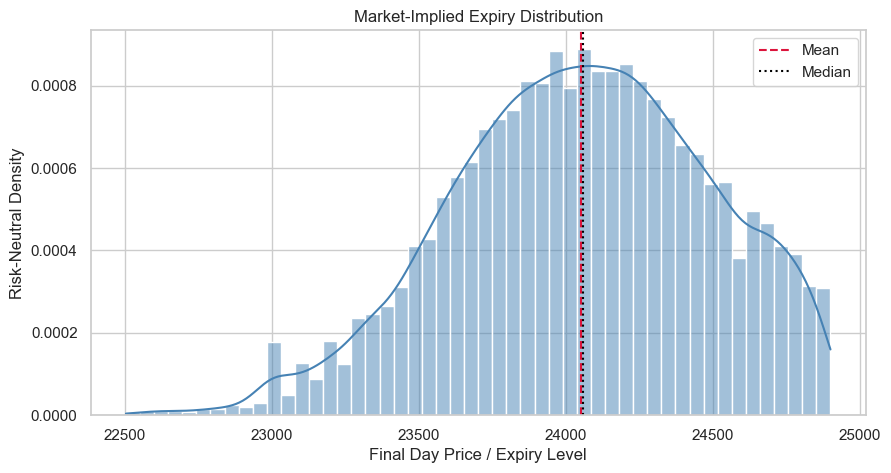

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    final_day_price_samples,
    bins=50,
    stat="density",
    kde=True,
    color="steelblue",
    edgecolor="white",
    ax=ax,
)

ax.axvline(dist["mean_implied_expiry_level"], color="crimson", linestyle="--", label="Mean")
ax.axvline(dist["quantiles"]["50%"], color="black", linestyle=":", label="Median")
ax.set_title("Market-Implied Expiry Distribution")
ax.set_xlabel("Final Day Price / Expiry Level")
ax.set_ylabel("Risk-Neutral Density")
ax.legend()
plt.show()

In [11]:
distribution_iv

0.1221119262246227